#  Exploratory Data Analysis

#### A notebook just to show whats been done!

In [1]:
import torch
print(f"Is CUDA available? {torch.cuda.is_available()}")
print(f"Device name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")

Is CUDA available? True
Device name: NVIDIA GeForce RTX 5080 Laptop GPU


In [5]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True, check=True)
print(result.stdout)

Tue Mar 24 15:13:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.71                 Driver Version: 595.71         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5080 ...  WDDM  |   00000000:02:00.0 Off |                  N/A |
| N/A   62C    P4             57W /   60W |   15980MiB /  16303MiB |    100%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")

FILE_PATH = Path.home() / "Documents" / "ESADE" / "ESADE" / "research" / "processed_earnings_calls" / "earnings_calls_combined_2018_current.csv"

df = pd.read_csv(FILE_PATH)
print(f"Loaded {len(df):,} rows from {FILE_PATH.name}")
df.head()

Loaded 114,365 rows from earnings_calls_combined_2018_current.csv


,gvkey,Year,transcriptId,componentText
0,1004,2018,1422577,"Good afternoon, ladies and gentlemen, and welc..."
1,1004,2018,1498980,"Good afternoon, ladies and gentlemen, and welc..."
2,1004,2018,1561209,"Good afternoon, ladies and gentlemen, and welc..."
3,1004,2018,1628558,"Good afternoon, ladies and gentlemen, and welc..."
4,1004,2019,1690328,"Good afternoon, ladies and gentlemen, and welc..."


## 2. Basic Structure

In [ ]:
print(f"Shape       : {df.shape}")
print(f"Columns     : {list(df.columns)}")
print()
print(df.dtypes)
print()
print("Missing values:")
print(df.isnull().sum())

In [2]:
print(f"Unique companies  (gvkey)     : {df['gvkey'].nunique():,}")
print(f"Unique transcripts            : {df['transcriptId'].nunique():,}")
print(f"Years covered                 : {sorted(df['Year'].unique())}")

Unique companies  (gvkey)     : 10,284
Unique transcripts            : 114,365
Years covered                 : [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]


## 3. Transcripts per Year

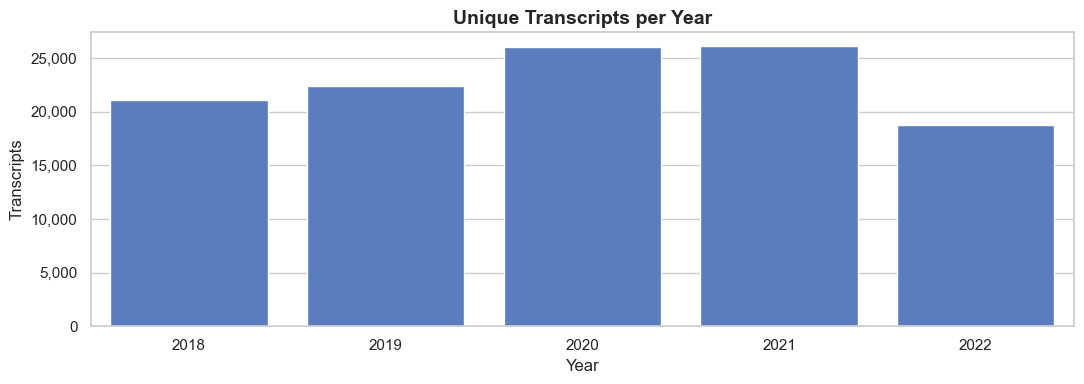

,Year,Transcripts
0,2018,21052
1,2019,22420
2,2020,26019
3,2021,26093
4,2022,18781


In [3]:
by_year = df.groupby("Year")["transcriptId"].nunique().reset_index(name="Transcripts")

fig, ax = plt.subplots(figsize=(11, 4))
sns.barplot(data=by_year, x="Year", y="Transcripts", ax=ax)
ax.set_title("Unique Transcripts per Year", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Transcripts")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()
by_year

## 4. Top 20 Companies by Number of Transcripts

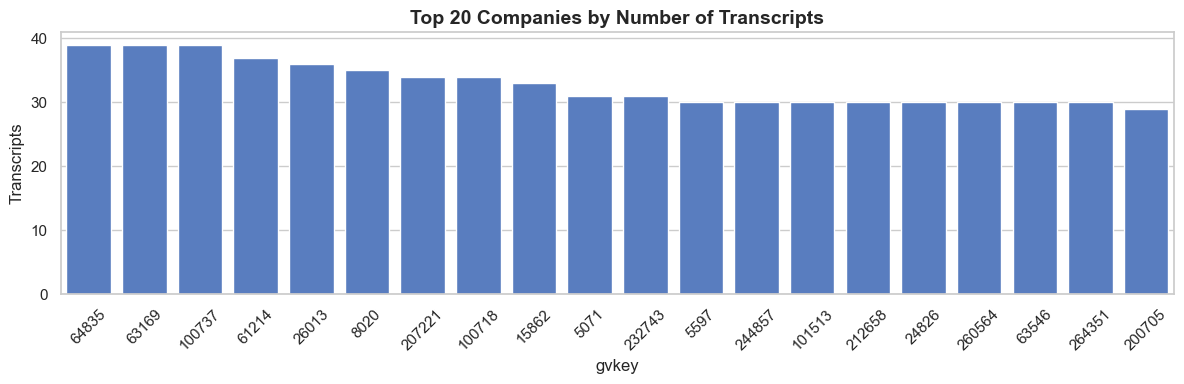

,gvkey,Transcripts
0,64835,39
1,63169,39
2,100737,39
3,61214,37
4,26013,36
5,8020,35
6,207221,34
7,100718,34
8,15862,33
9,5071,31


In [4]:
top_companies = (
    df.groupby("gvkey")["transcriptId"]
    .nunique()
    .sort_values(ascending=False)
    .head(20)
    .reset_index(name="Transcripts")
)
top_companies["gvkey"] = top_companies["gvkey"].astype(str)

fig, ax = plt.subplots(figsize=(12, 4))
sns.barplot(data=top_companies, x="gvkey", y="Transcripts", ax=ax)
ax.set_title("Top 20 Companies by Number of Transcripts", fontsize=14, fontweight="bold")
ax.set_xlabel("gvkey")
ax.set_ylabel("Transcripts")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()
top_companies

## 5. Transcript Text Length Distribution

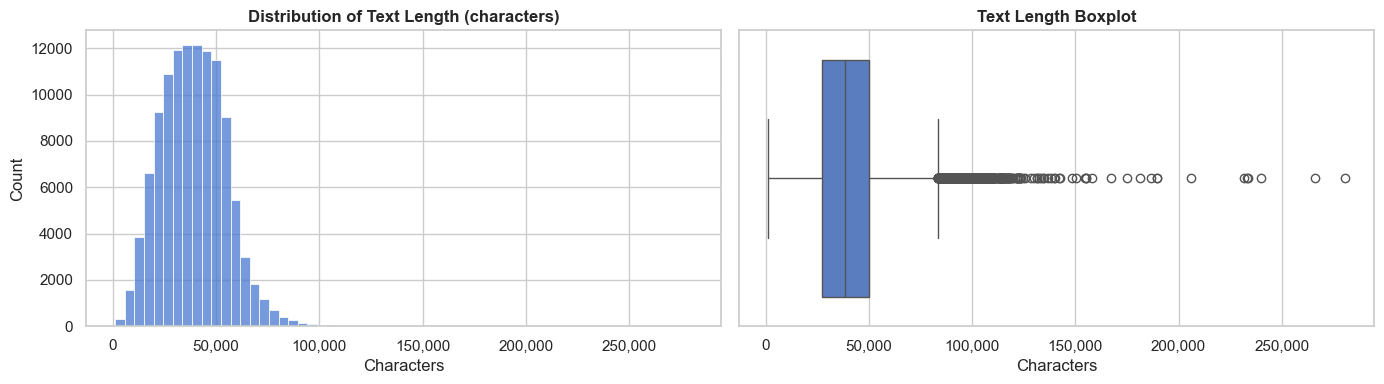

,char length
count,114364.000000
mean,39092.213022
std,15773.255925
min,1076.000000
25%,27412.750000
50%,38584.500000
75%,49778.000000
max,280674.000000


In [5]:
df["text_length"] = df["componentText"].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["text_length"], bins=60, ax=axes[0])
axes[0].set_title("Distribution of Text Length (characters)", fontweight="bold")
axes[0].set_xlabel("Characters")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

sns.boxplot(x=df["text_length"], ax=axes[1])
axes[1].set_title("Text Length Boxplot", fontweight="bold")
axes[1].set_xlabel("Characters")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()

df["text_length"].describe().rename("char length").to_frame()

## 6. Transcripts per Year — Coverage Heatmap (Top 50 Companies)

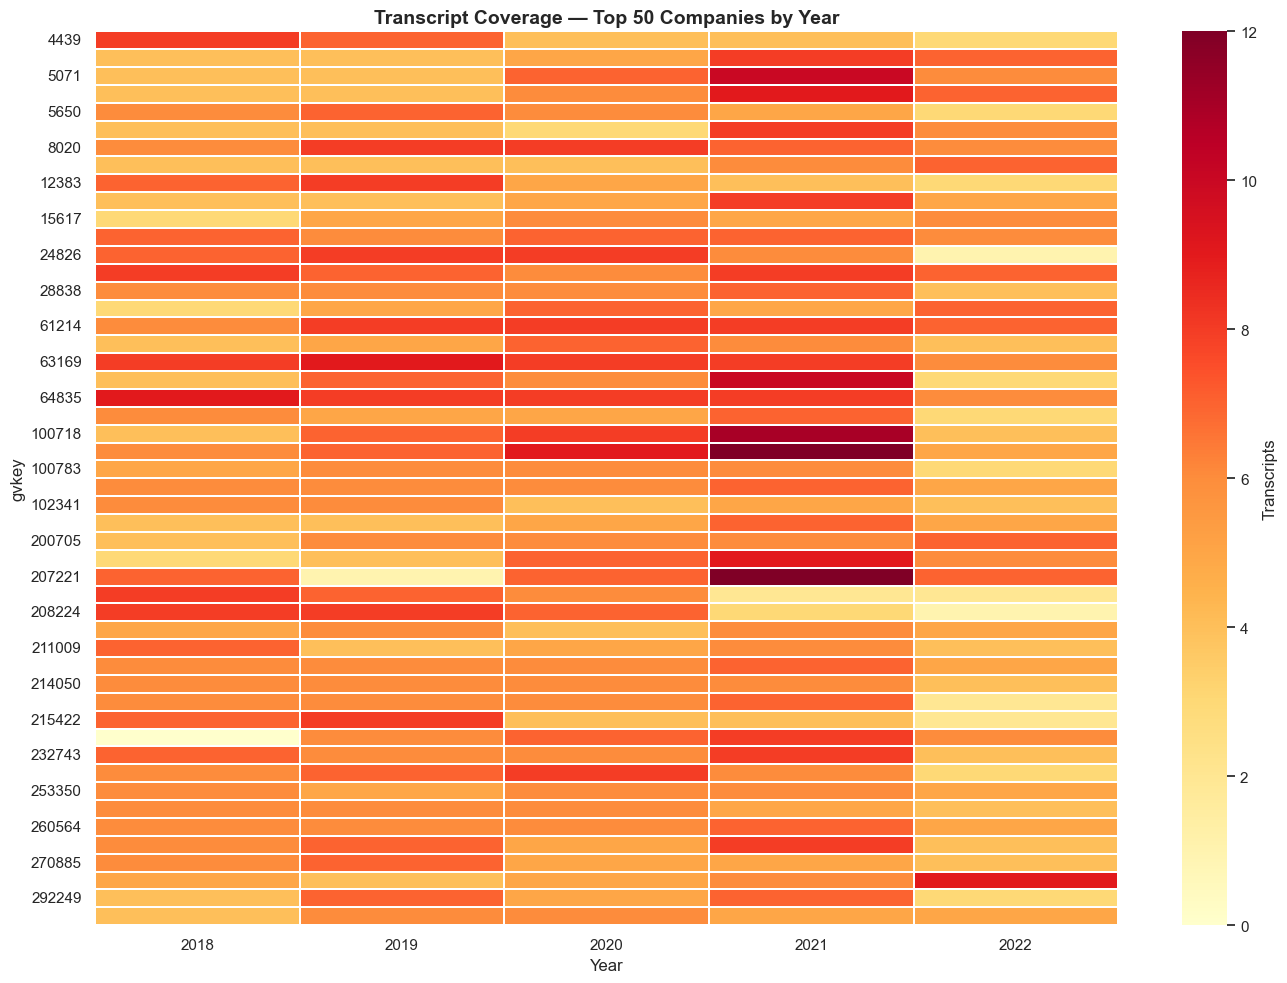

In [6]:
top50 = (
    df.groupby("gvkey")["transcriptId"].nunique()
    .sort_values(ascending=False)
    .head(50)
    .index
)

heatmap_data = (
    df[df["gvkey"].isin(top50)]
    .groupby(["gvkey", "Year"])["transcriptId"]
    .nunique()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(heatmap_data, cmap="YlOrRd", linewidths=0.3, ax=ax, cbar_kws={"label": "Transcripts"})
ax.set_title("Transcript Coverage — Top 50 Companies by Year", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("gvkey")
plt.tight_layout()
plt.show()

## 7. AAR Corp Deep-Dive (gvkey = 1004) — Our RAG Sample

AAR Corp transcripts : 23
Years covered        : [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]
Avg text length      : 27,865 chars


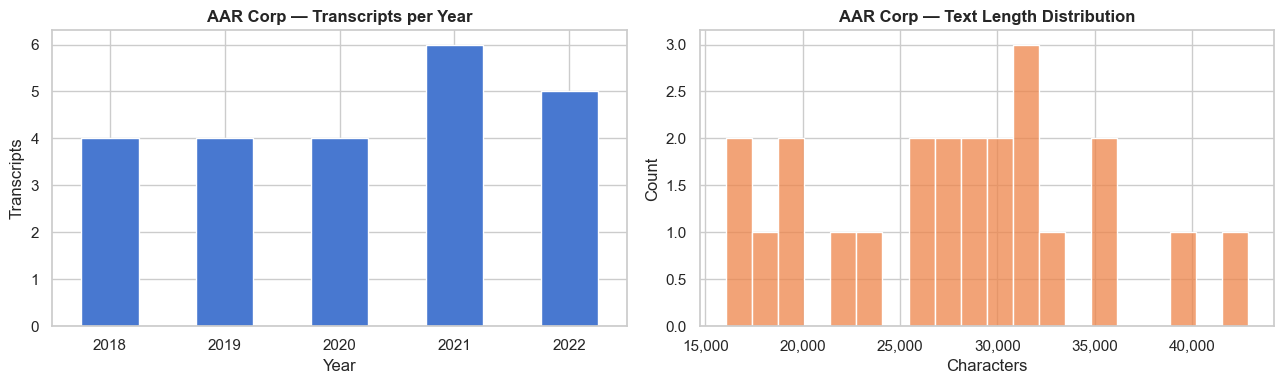

In [7]:
aar = df[df["gvkey"] == 1004].copy()

print(f"AAR Corp transcripts : {aar['transcriptId'].nunique()}")
print(f"Years covered        : {sorted(aar['Year'].unique())}")
print(f"Avg text length      : {aar['text_length'].mean():,.0f} chars")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

by_year_aar = aar.groupby("Year")["transcriptId"].nunique()
by_year_aar.plot(kind="bar", ax=axes[0], color=sns.color_palette("muted")[0])
axes[0].set_title("AAR Corp — Transcripts per Year", fontweight="bold")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Transcripts")
axes[0].tick_params(axis="x", rotation=0)

sns.histplot(aar["text_length"], bins=20, ax=axes[1], color=sns.color_palette("muted")[1])
axes[1].set_title("AAR Corp — Text Length Distribution", fontweight="bold")
axes[1].set_xlabel("Characters")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()

## 8. ChromaDB — Embedding Space (PCA)

Embedding matrix : (380, 4096)
Norm range       : 0.9963 – 1.0041


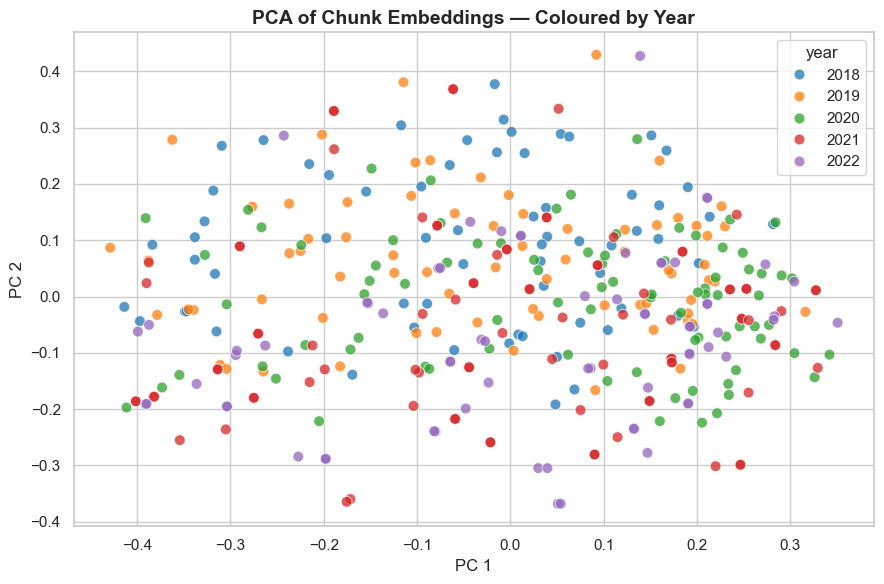

In [8]:
import numpy as np
import chromadb
from sklearn.decomposition import PCA

chroma_client = chromadb.PersistentClient(path="chroma_store")
collection    = chroma_client.get_collection("earnings_calls")

results = collection.get(include=["embeddings", "metadatas"])
embeddings = np.array(results["embeddings"])
meta_df    = pd.DataFrame(results["metadatas"])

print(f"Embedding matrix : {embeddings.shape}")
print(f"Norm range       : {np.linalg.norm(embeddings, axis=1).min():.4f} – {np.linalg.norm(embeddings, axis=1).max():.4f}")

pca    = PCA(n_components=2)
coords = pca.fit_transform(embeddings)
meta_df["pca_x"] = coords[:, 0]
meta_df["pca_y"] = coords[:, 1]
meta_df["year"]  = meta_df["year"].astype(str)

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=meta_df, x="pca_x", y="pca_y", hue="year", palette="tab10", alpha=0.75, s=60, ax=ax)
ax.set_title("PCA of Chunk Embeddings — Coloured by Year", fontsize=14, fontweight="bold")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
plt.tight_layout()
plt.show()